# 04 — K-Means Segmentation

Cluster customers on RFM features as a data-driven alternative to the
rule-based segments from nb 03.

Pipeline: signed-log transform + StandardScaler -> evaluate k in [2..10]
(elbow / silhouette / Davies-Bouldin / Calinski-Harabasz) -> fit final model
-> profile, label, and project clusters -> save `gold/customer_segments.parquet`.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

from src.config import load_settings
from src.viz import set_style
from src.segmentation import (
    preprocess_for_kmeans,
    evaluate_k,
    fit_kmeans,
    assign_clusters,
    cluster_profile,
    label_clusters,
)

set_style()

ROOT = Path.cwd().parent
settings = load_settings(ROOT / "config" / "settings.yaml")
SEED = settings["seed"]

FIG_DIR = ROOT / settings["paths"]["reports"] / "figures"
TBL_DIR = ROOT / settings["paths"]["reports"] / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"04_{name}.png", dpi=150, bbox_inches="tight")


def savetable(df, name):
    df.to_csv(TBL_DIR / f"04_{name}.csv")

In [2]:
rfm = pd.read_parquet(ROOT / settings["paths"]["gold"] / "rfm_table.parquet")
rfm.shape

(5336, 9)

## 1. Preprocess

Signed log transform (handles the few net-return customers with negative
Monetary), then standardize so all three features contribute equally to the
Euclidean distance.

In [3]:
X, scaler = preprocess_for_kmeans(
    rfm,
    log_transform=settings["kmeans"]["log_transform"],
    scaler=settings["kmeans"]["scaler"],
)
print("scaled feature matrix:", X.shape)
print("means ~0:", np.round(X.mean(axis=0), 3), " stds ~1:", np.round(X.std(axis=0), 3))

scaled feature matrix: (5336, 3)
means ~0: [ 0. -0.  0.]  stds ~1: [1. 1. 1.]


## 2. Evaluate k

In [4]:
metrics = evaluate_k(X, settings["k_range"], seed=SEED)
savetable(metrics.set_index("k"), "k_metrics")
metrics

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,7901.643843,0.438647,0.871347,5472.193272
1,3,5894.258979,0.348030,1.030660,4575.377409
2,4,4618.913720,0.366186,0.927130,4382.462415
3,5,3890.898595,0.341444,0.944436,4150.501161
4,6,3398.493044,0.335120,0.949385,3955.243086
5,7,3052.582927,0.296614,0.978937,3769.475626
6,8,2772.762668,0.298967,0.979296,3633.180418
7,9,2512.711444,0.321917,0.912822,3576.313284
8,10,2308.746685,0.298707,0.942820,3511.418574


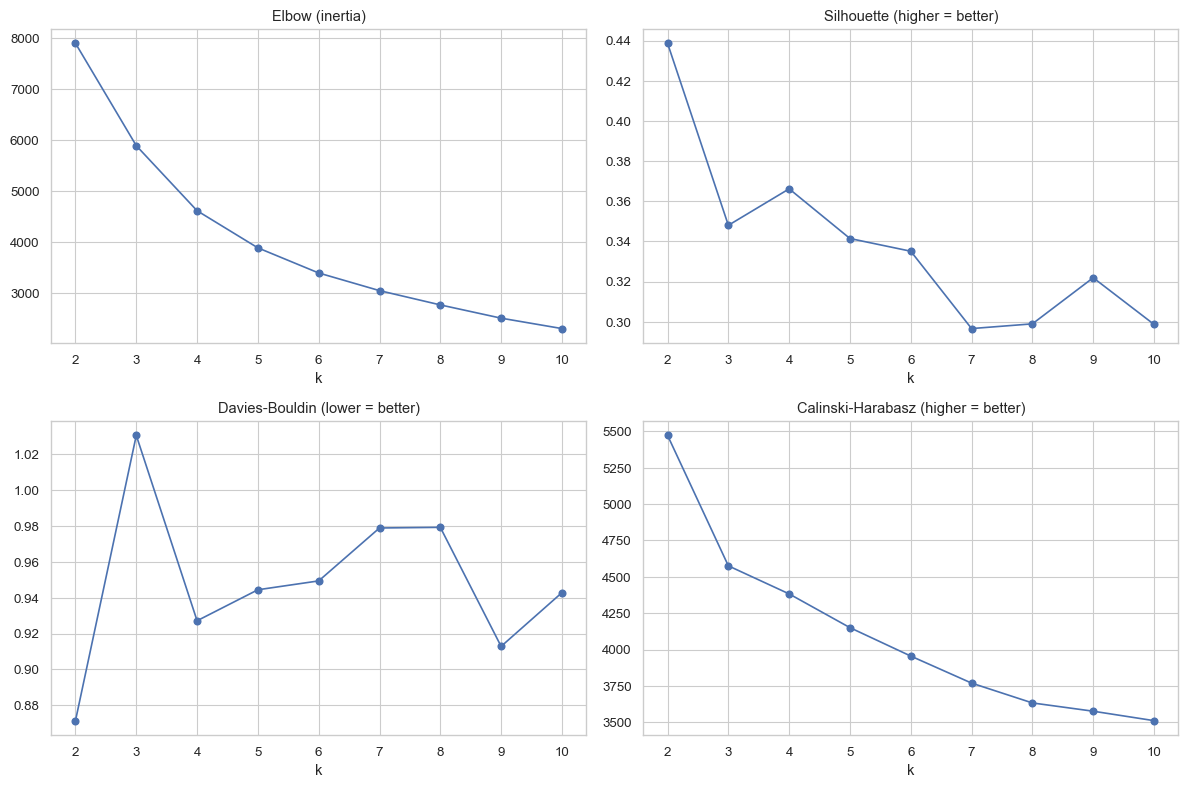

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
specs = [
    ("inertia", "Elbow (inertia)", "min", axes[0, 0]),
    ("silhouette", "Silhouette (higher = better)", "max", axes[0, 1]),
    ("davies_bouldin", "Davies-Bouldin (lower = better)", "min", axes[1, 0]),
    ("calinski_harabasz", "Calinski-Harabasz (higher = better)", "max", axes[1, 1]),
]
for col, title, _, ax in specs:
    ax.plot(metrics["k"], metrics[col], marker="o")
    ax.set_xlabel("k")
    ax.set_title(title)
fig.tight_layout()
savefig(fig, "k_evaluation")
plt.show()

## 3. Select k

The silhouette score is maximized at the trivial k=2, a known bias of the index
toward few, large clusters. We instead fix **k = `chosen_k`** (from
`settings.yaml`), selected by triangulating the **elbow** of the inertia curve
with the Davies-Bouldin and Calinski-Harabasz indices, and weighting business
interpretability: four tiers map onto distinct, actionable customer segments.
The silhouette optimum is reported below for transparency.

In [ ]:
silhouette_k = int(metrics.loc[metrics["silhouette"].idxmax(), "k"])
chosen_k = int(settings["kmeans"]["chosen_k"])
print(f"silhouette optimum: k={silhouette_k}  ->  chosen k={chosen_k}")
print(metrics.set_index("k").round(3))

## 4. Fit final model

In [ ]:
model = fit_kmeans(X, k=chosen_k, seed=SEED)
clustered = assign_clusters(rfm, model, X)
clustered["Cluster"].value_counts().sort_index()

## 5. Cluster profiles & labels

In [8]:
profile = cluster_profile(clustered)
labels = label_clusters(clustered)
profile["label"] = profile.index.map(labels)
clustered["ClusterLabel"] = clustered["Cluster"].map(labels)
savetable(profile, "cluster_profile")
profile.round(1)

,Recency,Frequency,Monetary,count,label
Cluster,,,,,
0,50.3,12.5,5583.8,2123,Champions
1,302.7,2.1,563.9,3213,Loyal


## 6. PCA projection (2D)

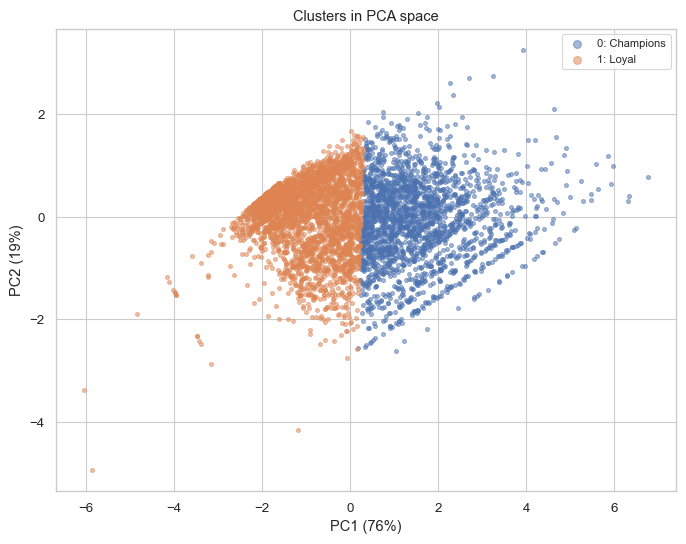

explained variance: [0.759 0.188]


In [9]:
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
for cid in sorted(clustered["Cluster"].unique()):
    m = clustered["Cluster"] == cid
    ax.scatter(coords[m, 0], coords[m, 1], s=8, alpha=0.5, label=f"{cid}: {labels[cid]}")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
ax.set_title("Clusters in PCA space")
ax.legend(markerscale=2, fontsize=8)
savefig(fig, "pca_scatter")
plt.show()
print("explained variance:", np.round(pca.explained_variance_ratio_, 3))

## 7. 3D RFM scatter

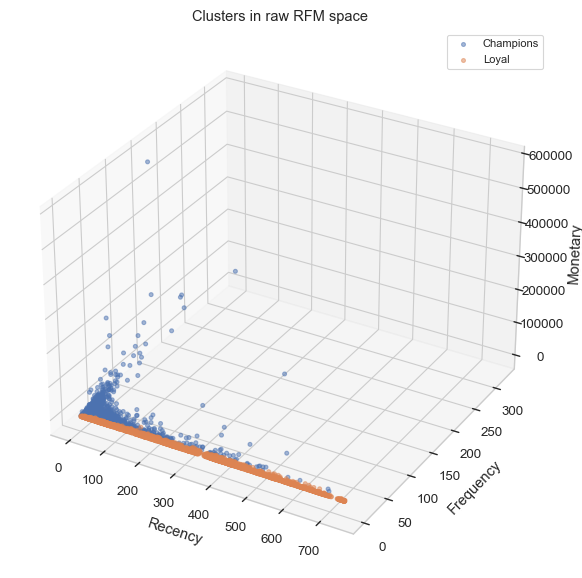

In [10]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
for cid in sorted(clustered["Cluster"].unique()):
    m = clustered["Cluster"] == cid
    ax.scatter(
        clustered.loc[m, "Recency"],
        clustered.loc[m, "Frequency"],
        clustered.loc[m, "Monetary"],
        s=8, alpha=0.5, label=f"{labels[cid]}",
    )
ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.set_title("Clusters in raw RFM space")
ax.legend(fontsize=8)
savefig(fig, "rfm_3d")
plt.show()

## 8. K-Means vs. rule-based segments

How the data-driven clusters relate to the traditional R/F-quintile segments
from nb 03.

In [11]:
xtab = pd.crosstab(clustered["ClusterLabel"], clustered["Segment"])
savetable(xtab, "kmeans_vs_traditional")
xtab

Segment,At Risk,Champions,Hibernating,Lost,Loyal
ClusterLabel,,,,,
Champions,112,1327,41,0,643
Loyal,634,12,1628,466,473


## 9. Save gold/customer_segments.parquet

In [ ]:
out_cols = ["Customer ID", "Recency", "Frequency", "Monetary", "Cluster", "ClusterLabel"]
out_path = ROOT / settings["paths"]["gold"] / "customer_segments.parquet"
clustered[out_cols].to_parquet(out_path, index=False)
print(f"saved: {out_path}  ({len(clustered)} customers, k={chosen_k})")

## Key findings

- **k selection.** Silhouette favours a small number of well-separated clusters;
  the elbow and Davies-Bouldin / Calinski-Harabasz indices are reported alongside
  for triangulation rather than relying on a single criterion.
- **Interpretable tiers.** Clusters are named by ranking their RFM centroids on a
  composite value score (low Recency, high Frequency, high Monetary), yielding
  marketing-interpretable tiers (Champions, Loyal, ...).
- **Convergence with the baseline.** The cross-tabulation shows substantial
  agreement between the data-driven clusters and the rule-based RFM segments,
  while K-Means additionally captures gradations the fixed quintile rules miss.
- **Reproducibility.** Fixed seed (42), explicit `n_init`, and a deterministic
  preprocessing pipeline make the segmentation fully reproducible.